In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


In [2]:
df = pd.read_csv("spambase_csv.csv")
df.head()


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

In [4]:
df.isnull().sum()


word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre

In [5]:
df.fillna(df.median(numeric_only=True), inplace=True)


In [6]:
X = df.drop("class", axis=1)
y = df["class"]


In [7]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print(X_scaled.describe())

       word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
count    4.601000e+03       4.601000e+03   4.601000e+03   4601.000000   
mean     1.853187e-17       2.779780e-17   2.470916e-17      0.000000   
std      1.000109e+00       1.000109e+00   1.000109e+00      1.000109   
min     -3.424337e-01      -1.650719e-01  -5.567606e-01     -0.046900   
25%     -3.424337e-01      -1.650719e-01  -5.567606e-01     -0.046900   
50%     -3.424337e-01      -1.650719e-01  -5.567606e-01     -0.046900   
75%     -3.424337e-01      -1.650719e-01   2.764271e-01     -0.046900   
max      1.452700e+01       1.090096e+01   9.560519e+00     30.641278   

       word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
count   4.601000e+03    4.601000e+03      4.601000e+03         4601.000000   
mean    4.941832e-17    3.706374e-17     -2.470916e-17            0.000000   
std     1.000109e+00    1.000109e+00      1.000109e+00            1.000109   
min    -4.643144e-01   -3.5026

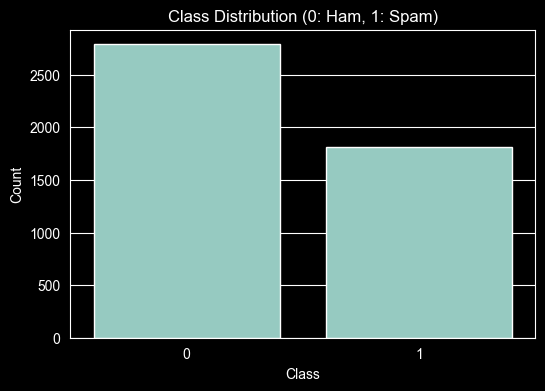

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Class Distribution (0: Ham, 1: Spam)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

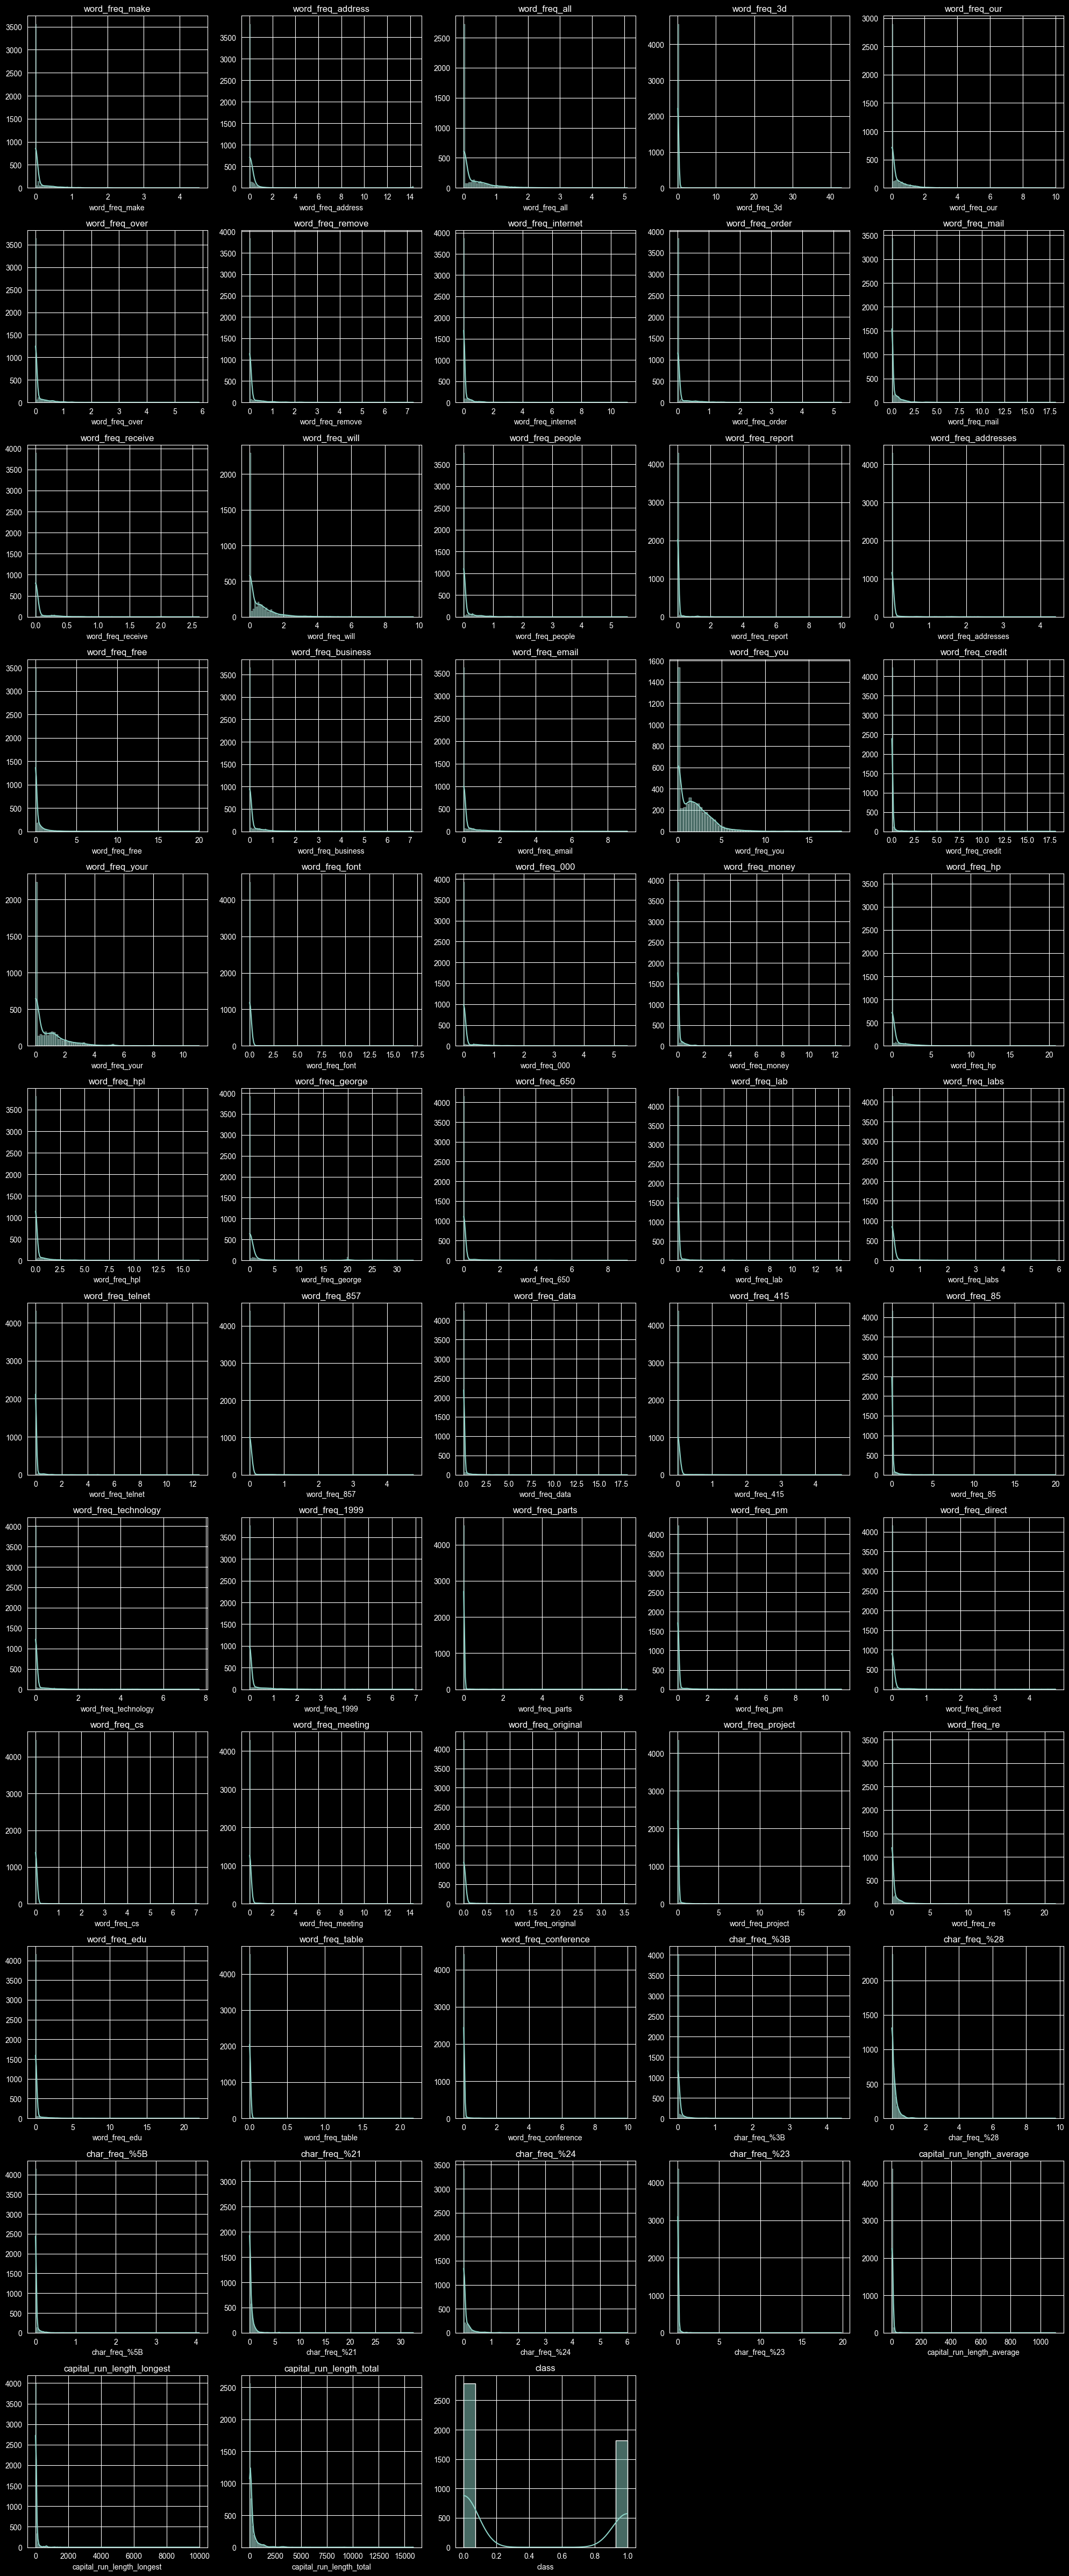

In [9]:
import math

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
n_cols = 5
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('')

for i in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

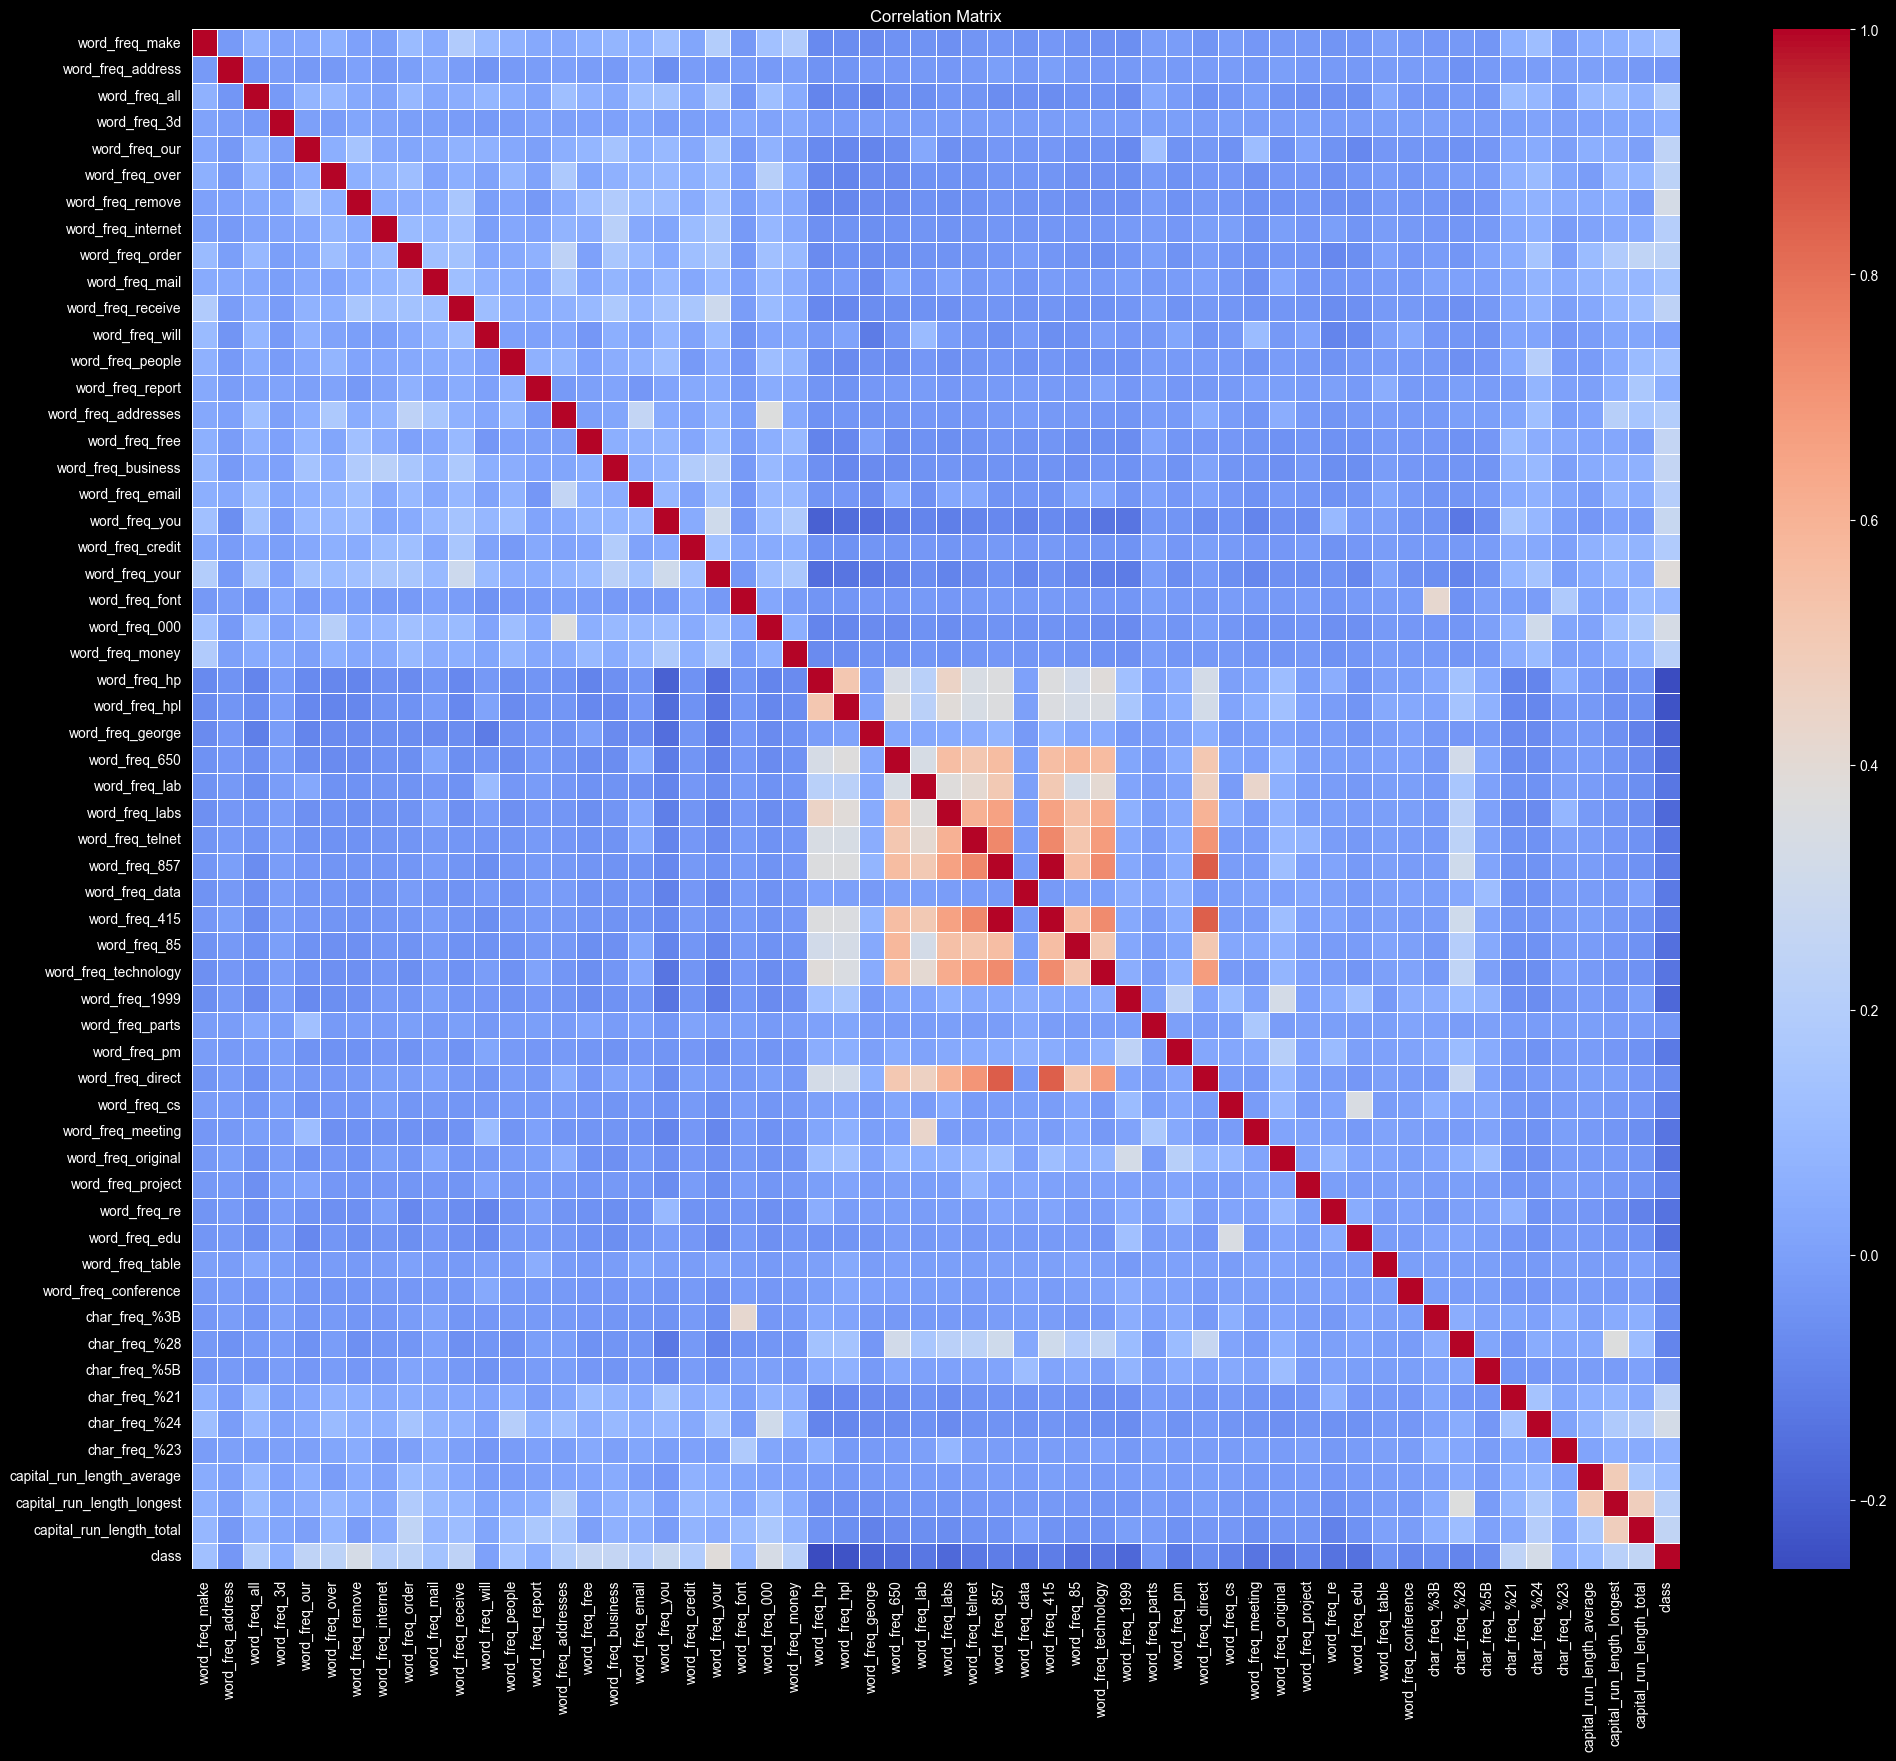

In [10]:
plt.figure(figsize=(24, 20))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [12]:
lr_start = time.time()
lr_base = LogisticRegression(max_iter=5000)
lr_base.fit(X_train, y_train)
lr_end = time.time()
lr_preds = lr_base.predict(X_test)

print(f"Baseline LR Training Time: {lr_end - lr_start:.4f} s")
print("Baseline LR Metrics:")
print(classification_report(y_test, lr_preds))

Baseline LR Training Time: 0.0204 s
Baseline LR Metrics:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       558
           1       0.92      0.90      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.93       921
weighted avg       0.93      0.93      0.93       921



In [13]:
param_grid_lr = {
    "C": [0.01, 0.1, 1, 10, 100],
    "l1_ratio": [0, 1],   # 0 = L2, 1 = L1
    "solver": ["saga"]
}

grid_lr = GridSearchCV(
    LogisticRegression(
        max_iter=5000
    ),
    param_grid_lr,
    cv=5,
    scoring="accuracy",
    verbose=1
)

grid_lr.fit(X_train, y_train)



Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=5000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'l1_ratio': [0, 1], 'solver': ['saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also dis

In [14]:
print(grid_lr.best_params_)
print(grid_lr.best_score_)

{'C': 1, 'l1_ratio': 1, 'solver': 'saga'}
0.9239130434782608


In [15]:
best_lr = grid_lr.best_estimator_

cv_lr = cross_val_score(
    best_lr,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Average CV Accuracy:", cv_lr.mean())


Average CV Accuracy: 0.9239130434782608


In [16]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results_svm = []

for k in kernels:
    svc_temp = SVC(kernel=k, max_iter=5000)
    start_t = time.time()
    svc_temp.fit(X_train, y_train)
    end_t = time.time()

    preds = svc_temp.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    results_svm.append({
        'Kernel': k,
        'Accuracy': acc,
        'F1 Score': f1,
        'Training Time (s)': end_t - start_t
    })

svm_df = pd.DataFrame(results_svm)
print(svm_df)

C:\Users\Saipranav\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Kernel  Accuracy  F1 Score  Training Time (s)
0   linear  0.916395  0.897196           0.140534
1     poly  0.779587  0.621974           0.221037
2      rbf  0.927253  0.905501           0.136110
3  sigmoid  0.883822  0.852414           0.140263


In [17]:
pd.DataFrame(results_svm).T


,0,1,2,3
Kernel,linear,poly,rbf,sigmoid
Accuracy,0.916395,0.779587,0.927253,0.883822
F1 Score,0.897196,0.621974,0.905501,0.852414
Training Time (s),0.140534,0.221037,0.13611,0.140263


In [18]:

param_grid_svm = [

    {'kernel': ['linear'], 'C': [0.1, 1, 10, 100]},


    {'kernel': ['rbf', 'sigmoid'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']},


    {'kernel': ['poly'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'], 'degree': [2, 3, 4]}
]


grid_svm = GridSearchCV(SVC(max_iter=5000), param_grid_svm, cv=3, n_jobs=-1, scoring='accuracy')
grid_svm.fit(X_train, y_train)

print("Best SVM Parameters:", grid_svm.best_params_)
print("Best SVM Cross-Validation Accuracy:", grid_svm.best_score_)

Best SVM Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM Cross-Validation Accuracy: 0.9342374957510748


In [19]:
results = pd.DataFrame(grid_svm.cv_results_)
results = results.sort_values(by='mean_test_score', ascending=False)
print(results[['param_kernel', 'param_C', 'mean_test_score', 'std_test_score']].head(10))

   param_kernel  param_C  mean_test_score  std_test_score
12          rbf     10.0         0.934237        0.004457
14          rbf     10.0         0.933966        0.004389
10          rbf      1.0         0.932064        0.003927
8           rbf      1.0         0.931792        0.003811
16          rbf    100.0         0.926356        0.009061
1        linear      1.0         0.926085        0.006213
18          rbf    100.0         0.926084        0.009679
0        linear      0.1         0.922279        0.010001
32         poly     10.0         0.911952        0.012364
33         poly     10.0         0.911680        0.012243


In [20]:
best_lr = grid_lr.best_estimator_
best_svm = grid_svm.best_estimator_

def evaluate_model_full(model, X_train, y_train, X_test, y_test, name):

    start_train = time.time()
    model.fit(X_train, y_train)
    end_train = time.time()
    train_time = end_train - start_train


    start_infer = time.time()
    preds = model.predict(X_test)
    end_infer = time.time()
    infer_time = end_infer - start_infer

    print(f"--- {name} Performance ---")
    print(f"Training Time: {train_time:.4f} s")
    print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
    print(f"Precision: {precision_score(y_test, preds):.4f}")
    print(f"Recall: {recall_score(y_test, preds):.4f}")
    print(f"F1 Score: {f1_score(y_test, preds):.4f}")
    print("-" * 30)

evaluate_model_full(best_lr, X_train, y_train, X_test, y_test, "Logistic Regression (Best)")
evaluate_model_full(best_svm, X_train, y_train, X_test, y_test, "SVM (Best)")

--- Logistic Regression (Best) Performance ---
Training Time: 5.4336 s
Accuracy: 0.9294
Precision: 0.9209
Recall: 0.8981
F1 Score: 0.9093
------------------------------
--- SVM (Best) Performance ---
Training Time: 0.1164 s
Accuracy: 0.9229
Precision: 0.9195
Recall: 0.8815
F1 Score: 0.9001
------------------------------


In [21]:
from sklearn.model_selection import cross_val_score


print("Running Cross-Validation... (this may take a moment)")
cv_lr_scores = cross_val_score(best_lr, X_scaled, y, cv=5)
cv_svm_scores = cross_val_score(best_svm, X_scaled, y, cv=5)


cv_table = pd.DataFrame({
    'Fold': ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5'],
    'Logistic Regression': cv_lr_scores,
    'SVM': cv_svm_scores
})


average_row = {
    'Fold': 'Average',
    'Logistic Regression': cv_lr_scores.mean(),
    'SVM': cv_svm_scores.mean()
}
cv_table = pd.concat([cv_table, pd.DataFrame([average_row])], ignore_index=True)


print("\n--- K-Fold Cross-Validation Results (K=5) ---")
print(cv_table.to_markdown(index=False))

Running Cross-Validation... (this may take a moment)

--- K-Fold Cross-Validation Results (K=5) ---
| Fold    |   Logistic Regression |      SVM |
|:--------|----------------------:|---------:|
| Fold 1  |              0.919653 | 0.935939 |
| Fold 2  |              0.928261 | 0.928261 |
| Fold 3  |              0.930435 | 0.943478 |
| Fold 4  |              0.941304 | 0.938043 |
| Fold 5  |              0.833696 | 0.852174 |
| Average |              0.91067  | 0.919579 |


| Param    | Meaning                         |
| -------- | ------------------------------- |
| C        | inverse regularization strength |
| l1_ratio | L1 vs L2 control                |
| solver   | optimization algorithm          |
| max_iter | training iterations             |


| Param  | Meaning                  |
| ------ | ------------------------ |
| kernel | decision boundary shape  |
| C      | margin vs error tradeoff |
| gamma  | influence radius         |
| degree | polynomial complexity    |
